In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Regression import PolynomialRegression, SinusoidalRegression

## Membuka Dataset

In [77]:
data = pd.read_csv("HistoricalDailyWeatherRecords.csv")

# Cek struktur data
data.head()

,date,station,daily_rainfall_total,highest_30_min_rainfall,highest_60_min_rainfall,highest_120_min_rainfall,mean_temperature,maximum_temperature,minimum_temperature,mean_wind_speed,max_wind_speed
0,2009-01-01,Admiralty,na,na,na,na,na,na,na,na,na
1,2009-01-02,Admiralty,na,na,na,na,na,na,na,na,na
2,2009-01-03,Admiralty,na,na,na,na,na,na,na,na,na
3,2009-01-04,Admiralty,na,na,na,na,na,na,na,na,na
4,2009-01-05,Admiralty,na,na,na,na,na,na,na,na,na


In [78]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2859 entries, 0 to 2858
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   date                      2859 non-null   object
 1   station                   2859 non-null   object
 2   daily_rainfall_total      2859 non-null   object
 3   highest_30_min_rainfall   2859 non-null   object
 4   highest_60_min_rainfall   2859 non-null   object
 5   highest_120_min_rainfall  2859 non-null   object
 6   mean_temperature          2859 non-null   object
 7   maximum_temperature       2859 non-null   object
 8   minimum_temperature       2859 non-null   object
 9   mean_wind_speed           2859 non-null   object
 10  max_wind_speed            2859 non-null   object
dtypes: object(11)
memory usage: 245.8+ KB


## Data Exploration

In [79]:
# Cek missing values
data.replace('na', np.nan, inplace=True) # Mengubah data dengan value 'na' menjadi null value yang bisa dibaca python
print(data.isnull().sum())

date                           0
station                        0
daily_rainfall_total         105
highest_30_min_rainfall     1755
highest_60_min_rainfall     1755
highest_120_min_rainfall    1755
mean_temperature             139
maximum_temperature          115
minimum_temperature          115
mean_wind_speed               96
max_wind_speed                97
dtype: int64


In [80]:
# Cek tipe data

print(data.dtypes)

date                        object
station                     object
daily_rainfall_total        object
highest_30_min_rainfall     object
highest_60_min_rainfall     object
highest_120_min_rainfall    object
mean_temperature            object
maximum_temperature         object
minimum_temperature         object
mean_wind_speed             object
max_wind_speed              object
dtype: object


In [81]:
# Karena datatype masih tidak cocok, maka diconvert sesuai yang tertulis di website

for col in data.columns:
    if col == 'date':
        data['date'] = pd.to_datetime(data['date'], format='%Y-%m-%d', errors='coerce')
    elif col == 'station':
        data['station'] = data['station'].astype(str)
    else:
        data[col] = pd.to_numeric(data[col], errors='coerce')

print(data.dtypes)

date                        datetime64[ns]
station                             object
daily_rainfall_total               float64
highest_30_min_rainfall            float64
highest_60_min_rainfall            float64
highest_120_min_rainfall           float64
mean_temperature                   float64
maximum_temperature                float64
minimum_temperature                float64
mean_wind_speed                    float64
max_wind_speed                     float64
dtype: object


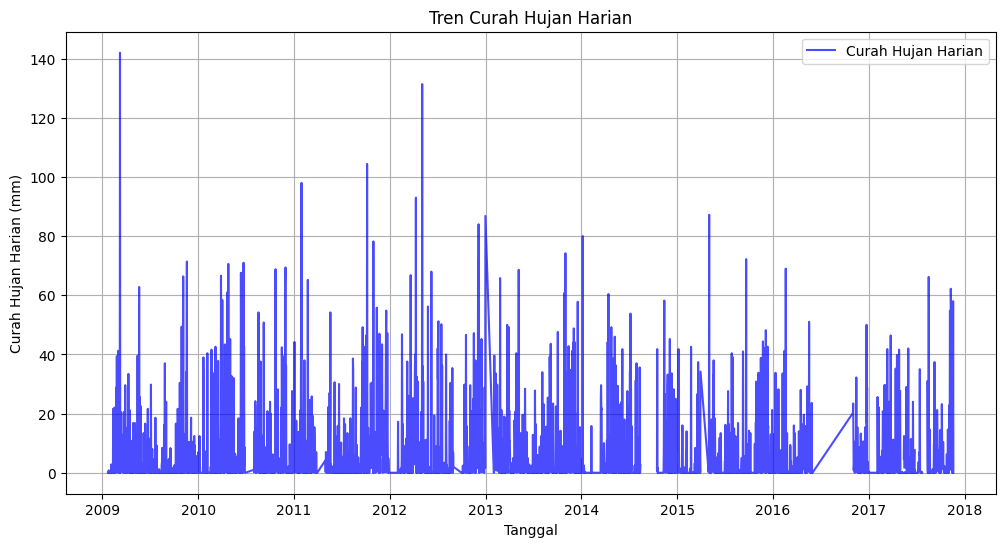

In [82]:
# Data Visualization

# Line plot untuk daily_rainfall_total terhadap waktu
plt.figure(figsize=(12, 6))
plt.plot(data['date'], data['daily_rainfall_total'], label='Curah Hujan Harian', color='blue', alpha=0.7)
plt.title('Tren Curah Hujan Harian')
plt.xlabel('Tanggal')
plt.ylabel('Curah Hujan Harian (mm)')
plt.legend()
plt.grid()
plt.show()

In [83]:
data.describe()

,date,daily_rainfall_total,highest_30_min_rainfall,highest_60_min_rainfall,highest_120_min_rainfall,mean_temperature,maximum_temperature,minimum_temperature,mean_wind_speed,max_wind_speed
count,2859,2754.000000,1104.000000,1104.000000,1104.000000,2720.000000,2744.000000,2744.000000,2763.000000,2762.000000
mean,2013-04-19 15:08:07.303252736,6.591903,3.668478,4.478080,4.993569,27.632059,31.749052,24.959111,7.846073,34.689066
min,2009-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,23.300000,24.200000,21.600000,3.700000,11.500000
25%,2011-01-16 12:00:00,0.000000,0.000000,0.000000,0.000000,26.800000,30.700000,24.200000,6.100000,28.400000
50%,2013-05-02 00:00:00,0.200000,0.200000,0.200000,0.200000,27.600000,32.000000,24.900000,7.100000,33.500000
75%,2015-06-15 12:00:00,6.800000,3.850000,4.400000,5.000000,28.500000,33.000000,25.700000,8.900000,39.200000
max,2017-11-30 00:00:00,142.000000,47.800000,57.400000,80.800000,30.800000,36.600000,28.500000,18.700000,86.800000
std,NaN,13.335983,7.119767,8.947346,10.102011,1.186947,1.772685,1.205388,2.437322,8.537456


## Data Cleaning

Untuk highest_30_min_rainfall, highest_60_min_rainfall, dan highest_120_min_rainfall akan kita hapus karena terlalu banyak data yang hilang

In [84]:
removed_columns = ['highest_30_min_rainfall', 'highest_60_min_rainfall', 'highest_120_min_rainfall']
data_clean = data.drop(columns=removed_columns)
data_clean.head()

,date,station,daily_rainfall_total,mean_temperature,maximum_temperature,minimum_temperature,mean_wind_speed,max_wind_speed
0,2009-01-01,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,Admiralty,NaN,NaN,NaN,NaN,NaN,NaN


Untuk sisanya, akan kita isi dengan methode forward fill dan backward fill. Ini dilakukan karena data berupa time series

In [ ]:
numerical_columns = data_clean.select_dtypes(include=[np.number]).columns.tolist()

data_clean[numerical_columns] = data_clean[numerical_columns].interpolate(method='polynomial', order=3, limit_direction='both')
data_clean.isnull().sum()

date                     0
station                  0
daily_rainfall_total    32
mean_temperature        34
maximum_temperature     32
minimum_temperature     32
mean_wind_speed         32
max_wind_speed          32
dtype: int64

In [86]:
# Hapus baris di awal dan akhir yang memiliki nilai null
data_clean = data_clean.dropna()
data_clean.head()

,date,station,daily_rainfall_total,mean_temperature,maximum_temperature,minimum_temperature,mean_wind_speed,max_wind_speed
23,2009-01-24,Admiralty,0.0,26.800000,31.4,24.4,11.7,38.2
24,2009-01-25,Admiralty,0.8,25.900000,27.8,24.4,12.7,38.2
25,2009-01-26,Admiralty,0.0,25.900000,29.6,23.7,12.4,42.5
26,2009-01-27,Admiralty,0.0,26.346644,30.2,23.7,10.4,38.9
27,2009-01-28,Admiralty,0.0,26.600000,31.9,23.7,10.3,32.4


In [87]:
# Convert 'date' to datetime
# data_clean['date'] = pd.to_datetime(data_clean['date'])

# Create a 'month' column for grouping
# data_clean['month'] = data_clean['date'].dt.to_period('M')

# Define aggregation function for each column
# agg_funcs = {
#     'station': lambda x: x.mode().iloc[0] if not x.mode().empty else None,
#     'daily_rainfall_total': 'mean',
#     'mean_temperature': 'mean',
#     'maximum_temperature': 'mean',
#     'minimum_temperature': 'mean',
#     'mean_wind_speed': 'mean',
#     'max_wind_speed': 'mean'
# }

# # Group by 'month' and apply the aggregation
# monthly_data = data_clean.groupby('month').agg(agg_funcs).reset_index()

# # Convert month back to datetime (start of each month)
# monthly_data['month'] = monthly_data['month'].dt.to_timestamp()
# monthly_data['month'] = monthly_data['month'].dt.strftime('%Y-%m')

# print("123");
# Show result
# monthly_data.head()

In [88]:
# data_clean.head()

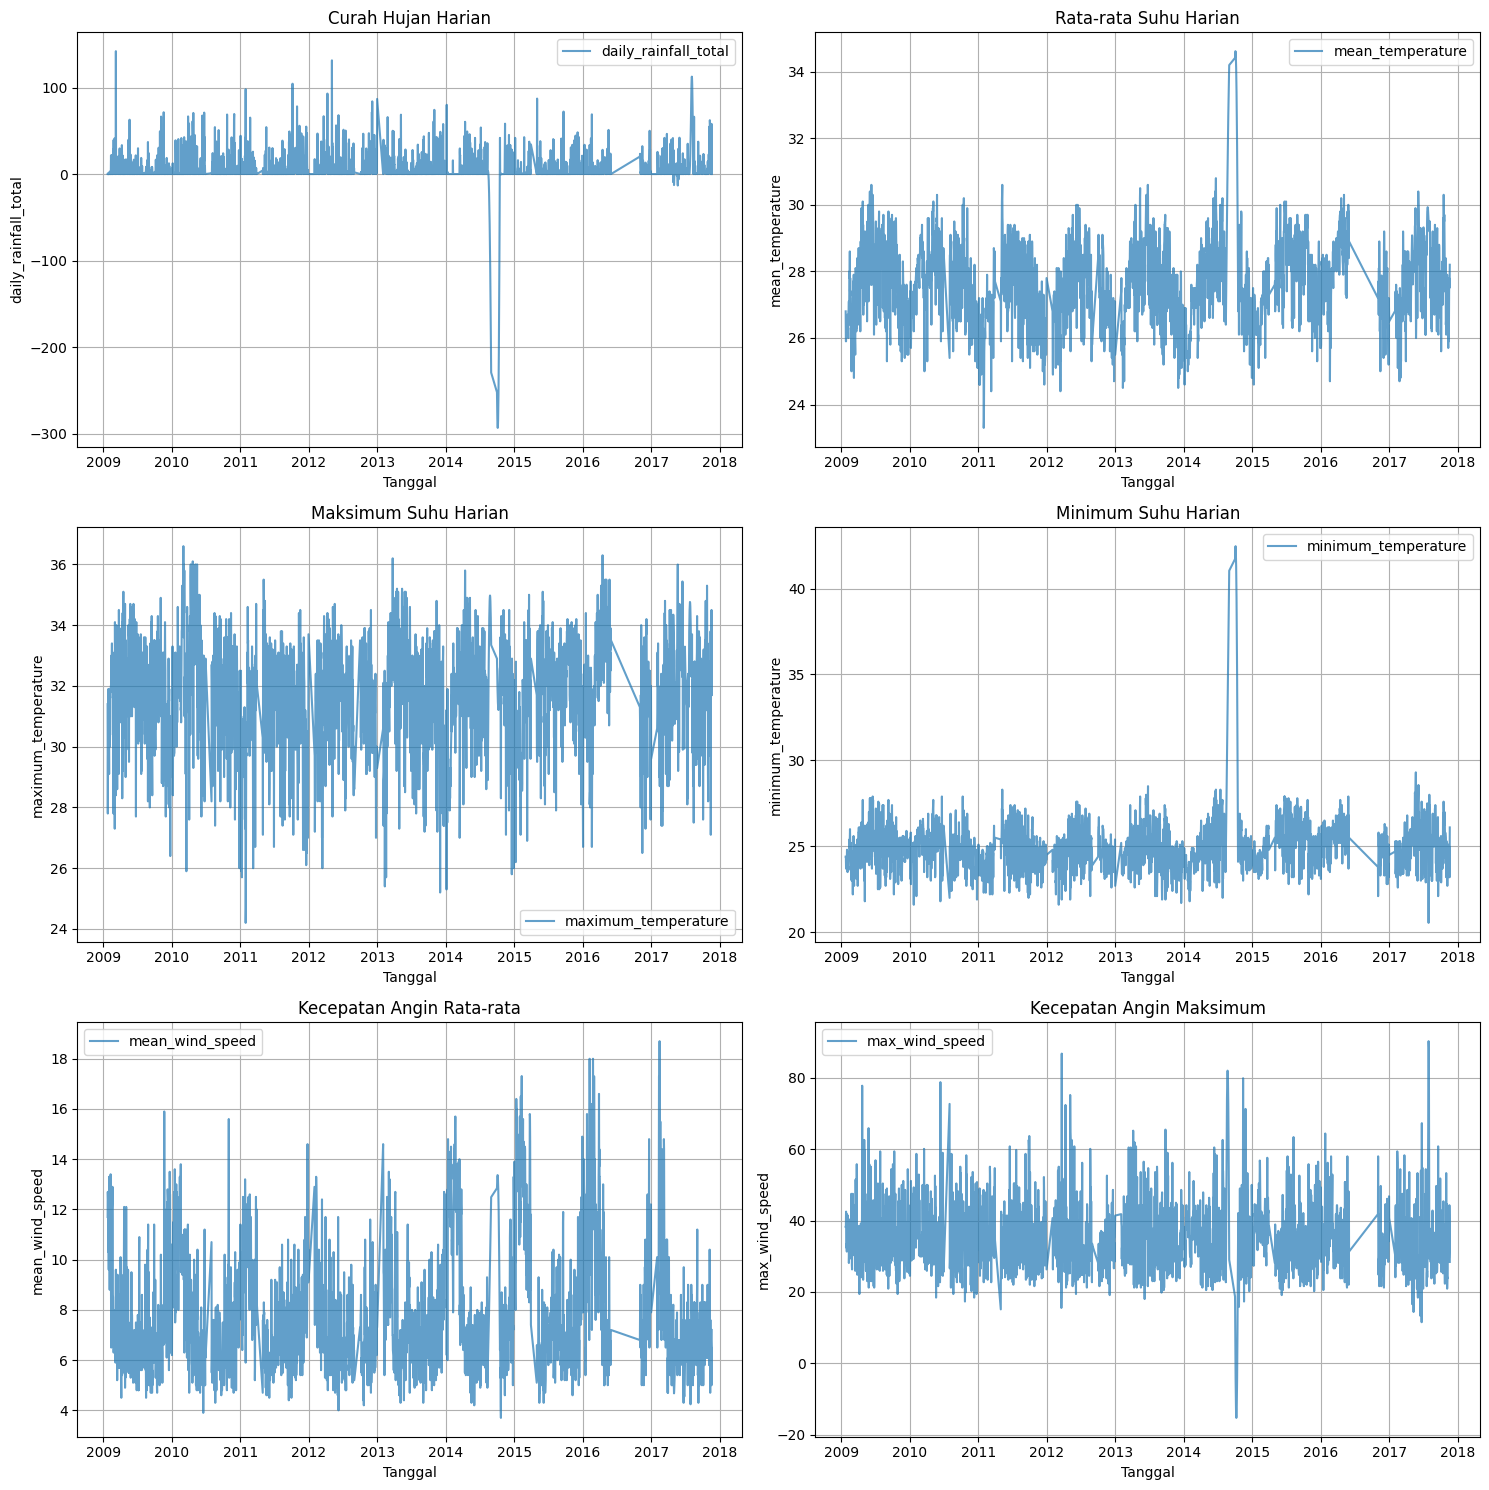

In [89]:
fig, axes = plt.subplots(3, 2, figsize=(15, 15))  # Create a 3x2 grid of subplots

columns_to_plot = numerical_columns  # Use the numerical columns for plotting
titles = [
    "Curah Hujan Harian",
    "Rata-rata Suhu Harian",
    "Maksimum Suhu Harian",
    "Minimum Suhu Harian",
    "Kecepatan Angin Rata-rata",
    "Kecepatan Angin Maksimum",
]

for ax, col, title in zip(axes.flatten(), columns_to_plot, titles):
    ax.plot(data_clean['date'], data_clean[col], label=col, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("Tanggal")
    ax.set_ylabel(col)
    ax.legend()
    ax.grid()

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

In [90]:
def split_data(data, target, test_size=0.2):
    """
    Splits the data into training and testing sets.
    
    Parameters:
    - data: DataFrame to be split
    - test_size: Proportion of the data to be used for testing
    
    Returns:
    - train_data: Training set
    - test_data: Testing set
    """
    train_size = int(len(data) * (1 - test_size))
    train_data = data[:train_size]
    test_data = data[train_size:]
    
    X_train = train_data.drop(columns=[target])
    y_train = train_data[target]
    X_test = test_data.drop(columns=[target])
    y_test = test_data[target]

    return X_train, y_train, X_test, y_test

In [96]:
monthly_data2 = data_clean.drop(['date', 'station', 'minimum_temperature', 'maximum_temperature', 'daily_rainfall_total', 'max_wind_speed', 'mean_wind_speed'], axis=1)  # Drop non-numeric columns for regression
monthly_data2 = monthly_data2[len(monthly_data2) - 90:]
monthly_data2['idx'] = range(1, len(monthly_data2) + 1)
# print(monthly_data2)
X_train, y_train, X_test, y_test = split_data(monthly_data2, target="mean_temperature", test_size=0.2)
X_train

,idx
2758,1
2759,2
2760,3
2761,4
2762,5
...,...
2825,68
2826,69
2827,70
2828,71


In [97]:
model = SinusoidalRegression(max_freq=50)
model.fit(X_train, y_train)


In [98]:
# print(model.getCoefficients())
# print(X_test)
# X = monthly_data2.drop(columns='mean_wind_speed')
# y = monthly_data2['mean_wind_speed']

y_pred = model.getAllPrediction(X_test)
print("EVAL=", model.eval(X_test, y_test))
print(y_pred)

EVAL= -14806.197489520104
0     -58.504020
1      36.422797
2      33.021780
3      -4.847846
4      63.167180
5    -102.681505
6     100.453103
7     -47.160344
8     137.982356
9      97.830022
10   -132.798448
11     61.808955
12     35.131154
13     65.193153
14    -87.237450
15    228.417406
16     -6.094949
17     73.052703
dtype: float64


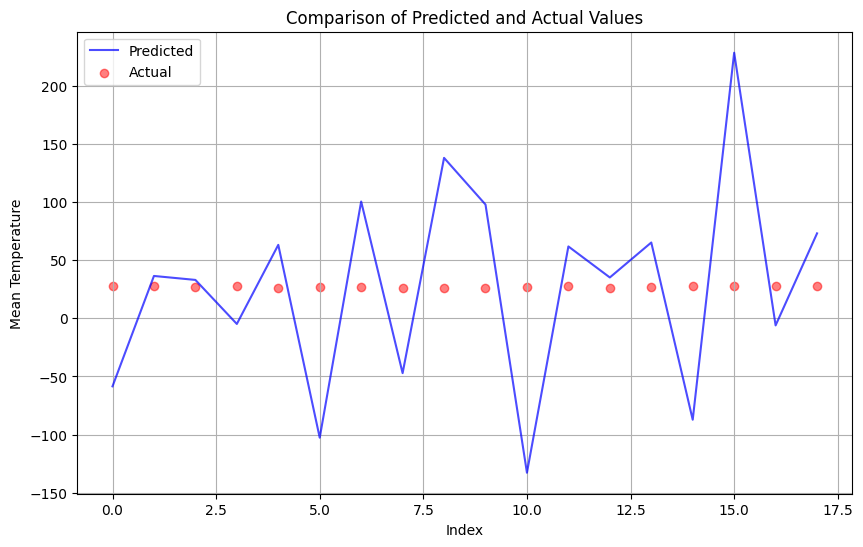

In [99]:
idx = [i for i in range(len(X_test))]  # Select every 100th index for plotting
plt.figure(figsize=(10, 6))
plt.plot(idx, y_pred, label="Predicted", color="blue", alpha=0.7)
plt.scatter(idx, y_test, label="Actual", color="red", alpha=0.5)
plt.title("Comparison of Predicted and Actual Values")
plt.xlabel("Index")
plt.ylabel("Mean Temperature")
plt.legend()
plt.grid()
plt.show()

In [95]:
data_clean.to_csv("data_clean.csv", index=False)